# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


# Load reqired libraries

In [17]:
import torch
import pickle
import ast
import numpy as np
import random
import time
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


Load the Data

In [ ]:

# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
# # Load and prepare data
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")

test_data = test_data.drop(columns=["model"])
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]

X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]



C:\Users\anuhe\AppData\Local\Temp\ipykernel_31036\3137228680.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_31036\3137228680.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

Target variables and input features

In [19]:
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]

X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]


In [20]:
train_data.head()



,sensor_data,label,velocity,mass,deceleration_average
0,"[[-5.730505819187293, 0.021809132292789083, -0...",3,21,1341.0,-4.874774
1,"[[-5.72556721671683, 0.0190849221728848, -0.34...",3,21,1341.0,-4.868881
2,"[[-5.880108022251814, 0.08222474189661085, -0....",3,20,1341.0,-5.098785
3,"[[-5.906634721955015, 0.059193506211250406, -0...",3,20,1341.0,-5.059594
4,"[[-5.474432312573297, 0.13487512855141023, -0....",3,20,1341.0,-4.774860


In [21]:
# Convert the Series of arrays into a single stacked NumPy array
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)


Sensor data value check

In [22]:
sensor_tensor = torch.tensor(X_train_sensor, dtype=torch.float32)
print("Min sensor value:", sensor_tensor.min().item())
print("Max sensor value:", sensor_tensor.max().item())


Min sensor value: -19.9156494140625
Max sensor value: 8.904726028442383


Sensor Data shape

4053 = number of samples

128 = sequence length (e.g. time steps)

6 = features per time step (e.g. 6 sensor channels)

In [23]:
print(X_train_sensor.shape)  # Should be (N, sequence_length, input_dim)


(4053, 128, 6)


In [24]:
# Drop sensor_data from tabular features
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])
print(X_train_tab)


      velocity    mass  deceleration_average
0           21  1341.0             -4.874774
1           21  1341.0             -4.868881
2           20  1341.0             -5.098785
3           20  1341.0             -5.059594
4           20  1341.0             -4.774860
...        ...     ...                   ...
4048        20  1530.0             -4.794934
4049        20  1530.0             -5.272853
4050        20  1530.0             -4.844974
4051        20  1530.0             -5.327936
4052        20  1530.0             -5.029897

[4053 rows x 3 columns]


Normalize X_train_tab

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)


           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          6.317576e-01
max    2.688413e+00  1.391196e+00          8.531451e+00


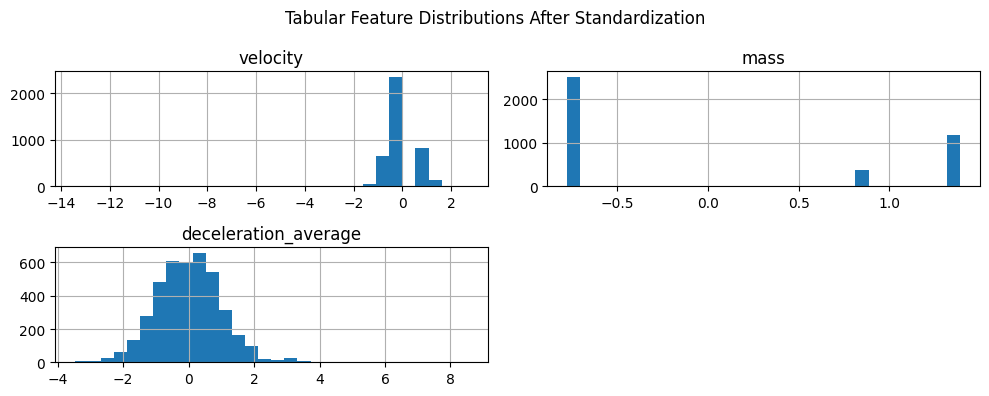

In [26]:
import pandas as pd

tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
import matplotlib.pyplot as plt

tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()


Check the distribution of all the sensor's data

In [27]:
flat = X_train_sensor.reshape(-1, X_train_sensor.shape[2])  # (4053 * 128, 6)

import pandas as pd
sensor_df = pd.DataFrame(flat, columns=[f"ch_{i}" for i in range(6)])
print(sensor_df.describe())


                ch_0           ch_1           ch_2           ch_3  \
count  518784.000000  518784.000000  518784.000000  518784.000000   
mean       -2.845372      -0.049401      -0.057974       0.058683   
std         3.218611       0.220883       0.281784       0.602134   
min        -9.073015      -2.902576      -1.513791      -8.808855   
25%        -5.852964      -0.091153      -0.203334      -0.167592   
50%        -3.733623      -0.019970      -0.087250       0.062211   
75%         0.246481       0.034066       0.080277       0.313486   
max         4.026857       1.281295       1.551846       8.904726   

                ch_4           ch_5  
count  518784.000000  518784.000000  
mean       -0.496792       0.050886  
std         1.812958       0.609783  
min       -12.567163     -19.915649  
25%        -0.959577      -0.184132  
50%        -0.180006       0.052122  
75%         0.356620       0.283430  
max         7.799918       3.573697  


Normalize X_train_sensor

### Sensor Data Normalization Strategy

**Shape:** `[N, 128, 6]`  
**Modality:** Sensor data (time-series)

**Technique:** Robust Scaling + Clipping

- **RobustScaler:** Applied to reduce sensitivity to outliers by using the median and interquartile range (IQR) instead of mean and standard deviation.
- **Clipping:** Values are clipped to the range `[-5, 5]` to limit the impact of extreme values.

**WHY:**  
Sensor signals often contain occasional outliers and noise, which can destabilize LSTM training. This two-step normalization approach preserves the core signal structure while ensuring numerical stability during training.


In [28]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# Flatten sensor data
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

# Fit robust scaler on training data only
scaler = RobustScaler()
flat_train_scaled = scaler.fit_transform(flat_train)
flat_test_scaled = scaler.transform(flat_test)

# Reshape back to original
X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

# Clip extreme values to range [-5, 5]
X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)


In [29]:
X_train_sensor_clipped

array([[[-0.32738766,  0.33364497, -0.82843678,  0.10297682,
          0.59181477,  0.68836714],
        [-0.32769496,  0.34972995, -0.89011383, -0.06388441,
          0.56245098,  0.66486859],
        [-0.33058313,  0.47033178, -0.95316155, -0.13459853,
          0.52557235,  0.64527961],
        ...,
        [ 0.69015567,  0.26899196,  0.52713754, -0.13945417,
         -0.0890666 , -0.31896294],
        [ 0.68813892,  0.24816918,  0.48170435, -0.25043067,
         -0.17719552, -0.31775962],
        [ 0.68646916,  0.20960942,  0.56407635, -0.35072305,
         -0.28040783, -0.32355309]],

       [[-0.32657798,  0.31188947, -0.91272833, -0.02875182,
          0.66865092,  0.34423923],
        [-0.32602275,  0.37360868, -0.98713222, -0.13029384,
          0.62015669,  0.35164132],
        [-0.32918791,  0.45993645, -1.05281064, -0.2386596 ,
          0.57921787,  0.36975815],
        ...,
        [ 0.6911374 ,  0.2649287 ,  0.57012992, -0.15746003,
         -0.08055529, -0.32973184],
  

Distribution of Sensor data after normalization

In [30]:
flat = X_train_sensor_clipped.reshape(-1, X_train_sensor.shape[2])  # (4053 * 128, 6)

import pandas as pd
sensor_df = pd.DataFrame(flat, columns=[f"ch_{i}" for i in range(6)])
print(sensor_df.describe())


                ch_0          ch_1           ch_2           ch_3  \
count  518784.000000  5.187840e+05  518784.000000  518784.000000   
mean        0.145628 -1.448858e-01       0.103211      -0.006518   
std         0.527689  1.157297e+00       0.993486       1.245378   
min        -0.875390 -5.000000e+00      -5.000000      -5.000000   
25%        -0.347465 -5.684702e-01      -0.409308      -0.477682   
50%         0.000000 -1.385322e-17       0.000000       0.000000   
75%         0.652535  4.315298e-01       0.590692       0.522318   
max         1.272326  5.000000e+00       5.000000       5.000000   

                ch_4           ch_5  
count  518784.000000  518784.000000  
mean       -0.237601       0.006578  
std         1.364892       1.161530  
min        -5.000000      -5.000000  
25%        -0.592290      -0.505288  
50%         0.000000       0.000000  
75%         0.407710       0.494712  
max         5.000000       5.000000  


Combining Tab features and sensor data for the LSTM

In [31]:

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import random
import pickle
import pandas as pd
import torch, numpy as np, random
class SensorDataset(Dataset):
    def __init__(self, sensor_seqs, tabular_feats, labels):
        self.sensor_seqs = torch.tensor(sensor_seqs, dtype=torch.float32)
        self.tabular_feats = torch.tensor(tabular_feats, dtype=torch.float32)

        # Ensure labels are converted safely
        if isinstance(labels, pd.Series):
            self.labels = torch.tensor(labels.values, dtype=torch.long)
        else:
            self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_seqs[idx], self.tabular_feats[idx], self.labels[idx]


In [32]:
train_dataset = SensorDataset(X_train_sensor_clipped, X_train_tab_scaled, y_train)
test_dataset = SensorDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Get the first batch from the DataLoader
for sensor_seq, tabular_feat, labels in train_loader:
    print("Sensor sequence shape:", sensor_seq.shape)     # (batch_size, 128, 6)
    print("Tabular features shape:", tabular_feat.shape)  # (batch_size, 3)
    print("Labels shape:", labels.shape)                  # (batch_size,)
    break


Sensor sequence shape: torch.Size([64, 128, 6])
Tabular features shape: torch.Size([64, 3])
Labels shape: torch.Size([64])


## Hyper parameter space

| Hyperparameter     | Affects                     | Low Value Effect                      | High Value Effect                           |
|--------------------|-----------------------------|----------------------------------------|----------------------------------------------|
| `hidden_dim`       | LSTM capacity               | Underfitting                           | Better learning, risk overfitting            |
| `num_layers`       | Temporal depth              | May miss complex patterns              | More powerful but slower                     |
| `bidirectional`    | Sequence context            | Only past info                         | Past + future info (better)                  |
| `dropout`          | Regularization              | May overfit                            | May underfit if too high                     |
| `tab_hidden_dim`   | Tabular feature capacity    | Too simple                             | More expressive tab handling                 |
| `batch_size`       | Training stability + speed  | Faster, noisier                        | Smoother, but slow updates                   |
| `learning_rate`    | Optimization speed + stability | Slow learning                     | May diverge if too large                     |


In [33]:
param_space = {
    'hidden_dim': [32, 64, 128],
    'num_layers': [1, 2],
    'bidirectional': [True, False],
    'dropout': [0.1, 0.3, 0.5],
    'tab_hidden_dim': [16, 32, 64],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}


In [34]:
def sample_hyperparams(param_space):
    return {k: random.choice(v) for k, v in param_space.items()}

def run_random_search_cv(sensor_data, tab_data, labels, num_trials=10, num_epochs=10, device='cuda'):
    best_f1 = -1
    best_params = None
    best_model_state = None

    for trial in range(num_trials):
        print(f"\nTrial {trial+1}/{num_trials}")

        # 1. Sample a random combination
        params = sample_hyperparams(param_space)
        print("Params:", params)

        all_f1_scores = []

        for split in range(10):
            # 2. Random split
            X_tr, X_val, T_tr, T_val, y_tr, y_val = train_test_split(
                sensor_data, tab_data, labels,
                test_size=0.2, stratify=labels, random_state=split + trial * 100
            )

            # 3. Create datasets and loaders
            train_ds = SensorDataset(X_tr, T_tr, y_tr)
            val_ds = SensorDataset(X_val, T_val, y_val)

            train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)

            # 4. Model
            model = LSTMClassifier(
                input_dim=sensor_data.shape[2],
                hidden_dim=params['hidden_dim'],
                num_layers=params['num_layers'],
                tabular_dim=tab_data.shape[1],
                tab_hidden_dim=params['tab_hidden_dim'],
                output_dim=len(np.unique(labels)),
                dropout=params['dropout'],
                bidirectional=params['bidirectional']
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            criterion = nn.CrossEntropyLoss()

            # 5. Train
            for epoch in range(num_epochs):
                train_one_epoch(model, train_loader, optimizer, criterion, device)

            # 6. Evaluate F1
            f1 = evaluate_f1(model, val_loader, device)
            all_f1_scores.append(f1)

        avg_f1 = np.mean(all_f1_scores)
        print(f"Average F1 score: {avg_f1:.4f}")

        # 7. Track and save best
        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = params
            best_model_state = model.state_dict()

            # Save best model to disk
            torch.save(best_model_state, "base_best_model.pth")

    print("\nBest Hyperparameters Found:")
    print(best_params)
    print(f"Best Average F1: {best_f1:.4f}")

    return best_params, best_f1, best_model_state


In [35]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2, tabular_dim=3,
                 tab_hidden_dim=32, output_dim=12, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        lstm_out, _ = self.lstm(x_seq)             # (batch, seq_len, hidden)
        lstm_last = lstm_out[:, -1, :]             # last time step
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((lstm_last, tab_out), dim=1)
        return self.classifier(combined)


In [36]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x_seq, x_tab, y in dataloader:
        x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x_seq, x_tab)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


In [37]:
from sklearn.metrics import f1_score

def evaluate_f1(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return f1_score(all_labels, all_preds, average='weighted')


In [40]:
# Perform random search cross-validation to find the best hyperparameters for the LSTM model.
# This will train multiple models with different hyperparameter combinations and select the best one based on F1 score.
best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=X_train_sensor_clipped,
    tab_data=X_train_tab_scaled,
    labels=y_train,
    num_trials=10,        # number of hyperparameter combinations
    num_epochs=10,        # training epochs per trial
    device='cuda' if torch.cuda.is_available() else 'cpu'
)



Trial 1/10
Params: {'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.3, 'tab_hidden_dim': 16, 'learning_rate': 0.0005, 'batch_size': 128}
Average F1 score: 0.9036

Trial 2/10
Params: {'hidden_dim': 128, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.0001, 'batch_size': 64}
Average F1 score: 0.8555

Trial 3/10
Params: {'hidden_dim': 128, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.5, 'tab_hidden_dim': 16, 'learning_rate': 0.0001, 'batch_size': 32}
Average F1 score: 0.7346

Trial 4/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.0005, 'batch_size': 128}
Average F1 score: 0.7856

Trial 5/10
Params: {'hidden_dim': 64, 'num_layers': 2, 'bidirectional': True, 'dropout': 0.1, 'tab_hidden_dim': 32, 'learning_rate': 0.001, 'batch_size': 32}
Average F1 score: 0.9831

Trial 6/10
Params: {'hidden_dim': 128, 'num_layers': 2, 'bidirectio

In [41]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild the best model architecture using best_params
final_model = LSTMClassifier(
    input_dim=X_test_sensor_clipped.shape[2],
    hidden_dim=best_params['hidden_dim'],
    num_layers=best_params['num_layers'],
    tabular_dim=X_test_tab_scaled.shape[1],
    tab_hidden_dim=best_params['tab_hidden_dim'],
    output_dim=len(np.unique(y_train)),  # same number of classes
    dropout=best_params['dropout'],
    bidirectional=best_params['bidirectional']
).to(device)


In [42]:
final_model.load_state_dict(torch.load("base_best_model.pth"))
final_model.eval()


LSTMClassifier(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (tabular_net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=160, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)

C:\Users\anuhe\AppData\Local\Temp\ipykernel_31036\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_31036\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          6.317576e-01
max    2.688413e+00  1.391196e+00          8.531451e+00


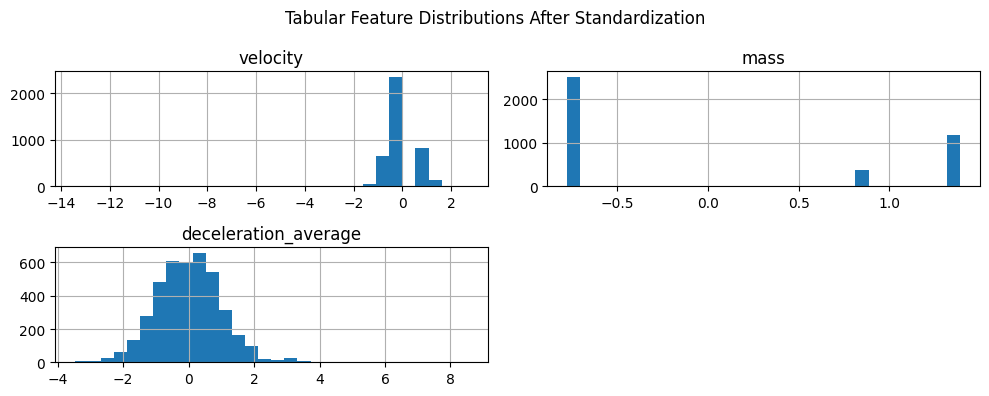

In [45]:
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Load and prepare data
train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")

train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

# Separate sensor and tabular data
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# Combine tabular data for KNN imputation
X_combined = pd.concat([X_train_tab, X_test_tab], ignore_index=True)

# Perform KNN imputation on the combined tabular data
imputer = KNNImputer(n_neighbors=5)
X_combined_imputed = imputer.fit_transform(X_combined)

# Split back the imputed data into train and test
X_train_tab_imputed = X_combined_imputed[:len(X_train_tab)]
X_test_tab_imputed = X_combined_imputed[len(X_train_tab):]

# Standardize the tabular data
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab_imputed)
X_test_tab_scaled = scaler.transform(X_test_tab_imputed)

# Optionally visualize
tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()

# Sensor preprocessing
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

sensor_scaler = RobustScaler()
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)

X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)


In [46]:
test_dataset = SensorDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)


In [47]:
final_f1 = evaluate_f1(final_model, test_loader, device)
print(f"Final Test F1 Score: {final_f1:.4f}")


Final Test F1 Score: 0.3729


# Confusion matrix

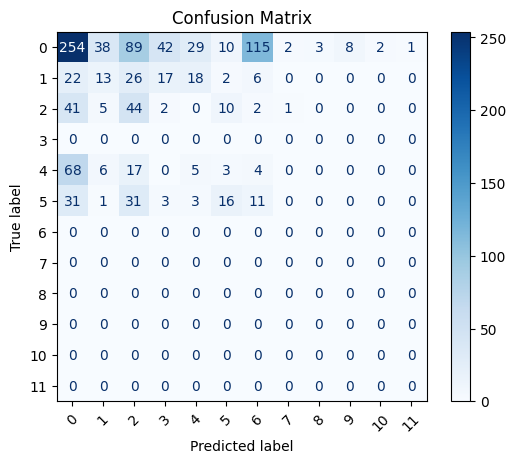

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Collect all predictions and true labels
all_preds = []
all_labels = []

final_model.eval()
with torch.no_grad():
    for sensor_data, tab_data, labels in test_loader:
        sensor_data = sensor_data.to(device)
        tab_data = tab_data.to(device)
        labels = labels.to(device)

        outputs = final_model(sensor_data, tab_data)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
